0.37467360318911636


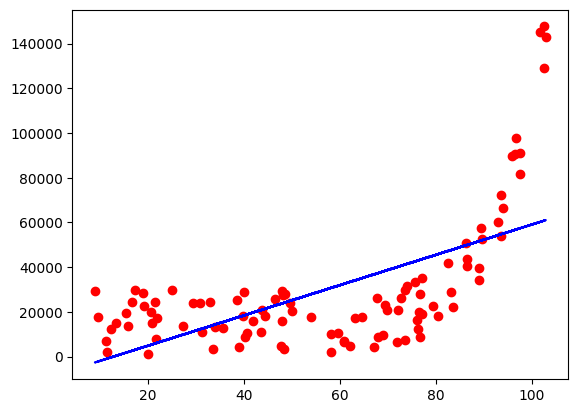

In [1]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, LogisticRegression
import pandas as pd
import numpy as np
from sklearn import metrics
from matplotlib import pyplot as plt
import time

data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML3.1%20polynomial%20features/data/gen_regression.csv")
x = data[['x']]
y = data.y

result = []
model = LinearRegression()
start = time.time()
model.fit(x, y)
end = time.time() - start
pred = model.predict(x)

result.append({'Model': 'Linear gen_regression', 'Time': end, 'Score': model.score(x, y)})

print(model.score(x, y))
plt.scatter(x, y, color='red')
plt.plot(x, pred, color='blue')
plt.show()



0.7359753787024842


C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


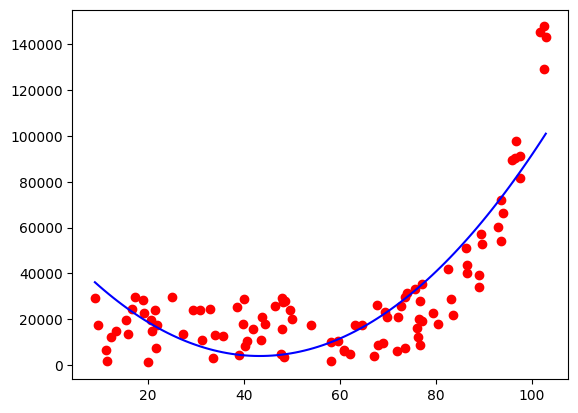

In [2]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)

model_poly = LinearRegression()
start = time.time()
model_poly.fit(x_poly, y)
end = time.time() - start
result.append({'Model': 'Poly gen_regression', 'Time': end, 'Score': model_poly.score(x_poly, y)})
pred = model_poly.predict(x_poly)
print(model_poly.score(x_poly, y))
xx = np.linspace(x.min().values[0], x.max().values[0], len(x)).reshape(-1, 1)
xx_poly = poly.transform(xx)
plt.scatter(x, y, color='red')
plt.plot(xx, model_poly.predict(xx_poly), color='blue')
plt.show()

0.832


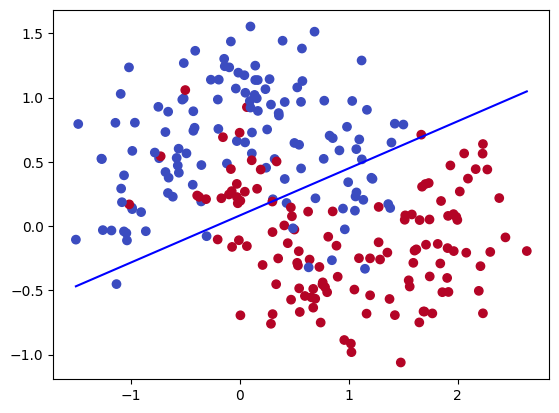

In [3]:
data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/gen_classification.csv",
                   index_col=0)

y = data.y
x = data.drop('y', axis=1)

logreg = LogisticRegression()
start = time.time()
logreg.fit(x, y)
end = time.time() - start
result.append({'Model': 'Line gen_classification', 'Time': end, 'Score': logreg.score(x, y)})
pred2 = logreg.predict(x)
print(logreg.score(x, y))

w0, w1, w2  = [logreg.intercept_[0], logreg.coef_[0][0], logreg.coef_[0][1]]
x_val =  np.array([x.iloc[:, 0].min(), x.iloc[:, 0].max()])
y_val = -(w0 + w1 * x_val) / w2

plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=y, cmap='coolwarm')
plt.plot(x_val, y_val, color='blue')
plt.show()

0.9


C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


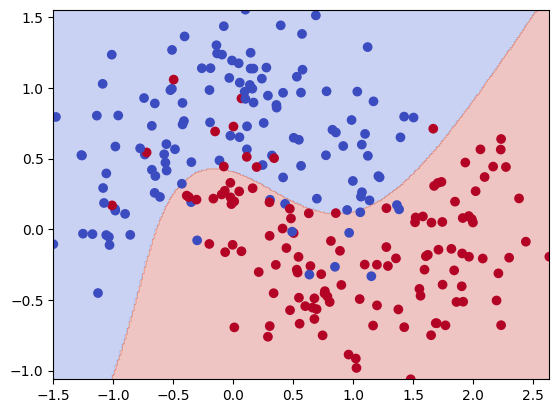

In [4]:
poly_class = PolynomialFeatures(degree=3, include_bias=False)
x_poly = poly_class.fit_transform(x)

class_poly = LogisticRegression()
start = time.time()
class_poly.fit(x_poly, y)
end = time.time() - start
result.append({'Model': 'Poly gen_classification', 'Time': end, 'Score': class_poly.score(x_poly, y)})
print(class_poly.score(x_poly, y))

xx, yy = np.meshgrid(
    np.linspace(x.iloc[:,0].min(), x.iloc[:,0].max(), 300),
    np.linspace(x.iloc[:,1].min(), x.iloc[:,1].max(), 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
grid_poly = poly_class.transform(grid)
Z = class_poly.predict(grid_poly).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=y, cmap='coolwarm')
plt.show()

0.699747189010915
bedrooms -35766.54144361757
bathrooms 41144.27853231529
sqft_living 110.44286455917374
sqft_lot 0.1285978691213336
floors 6689.550115069906
waterfront 582960.4584234959
view 52870.94238428882
condition 26385.64913860071
grade 95890.44515147021
sqft_above 70.78522437648168
sqft_basement 39.65764001116292
yr_built -2620.223211295074
yr_renovated 19.812583709286823
zipcode -582.4198656401695
lat 602748.226448565
long -214729.8282533195
sqft_living15 21.681400461426325
sqft_lot15 -0.38264184954823577


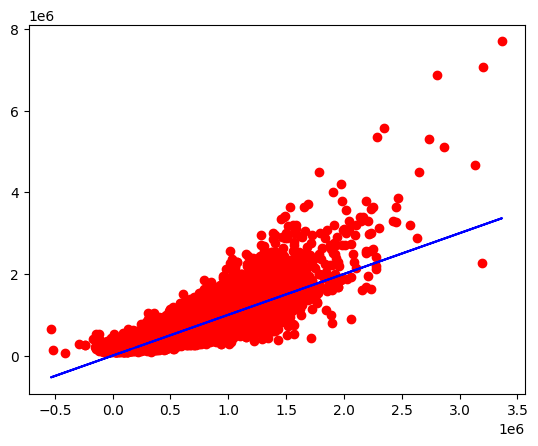

In [5]:
data_kc_prices = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/kc_house_data.csv")
y_kc_prices = data_kc_prices.price
X_kc_prices = data_kc_prices.drop(["id", "date", "price"], axis=1)

regr_kc = LinearRegression()
start = time.time()
regr_kc.fit(X_kc_prices, y_kc_prices)
end = time.time() - start
result.append({'Model': 'Line kc_house_data', 'Time': end, 'Score': regr_kc.score(X_kc_prices, y_kc_prices)})
print(regr_kc.score(X_kc_prices, y_kc_prices))
pred_kc = regr_kc.predict(X_kc_prices)
_ = [print(k, v) for k, v in zip(X_kc_prices.columns, regr_kc.coef_)]

plt.scatter(pred_kc, y_kc_prices, color='red')
plt.plot(pred_kc, pred_kc, color='blue')
plt.show()

0.8326020796539016


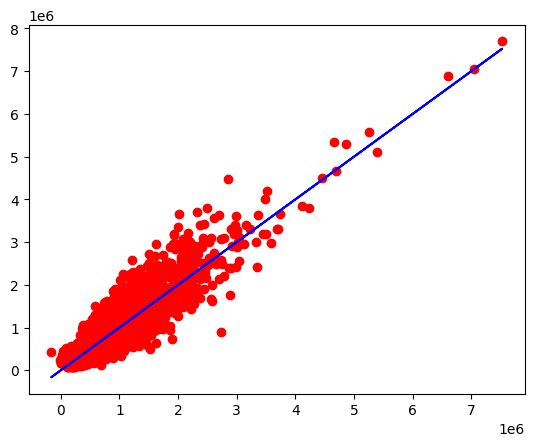

In [6]:
poly_kc = PolynomialFeatures(degree=3)
x_kc_poly = poly_kc.fit_transform(X_kc_prices)

regr_kc_poly = LinearRegression()
start = time.time()
regr_kc_poly.fit(x_kc_poly, y_kc_prices)
end = time.time() - start
result.append({'Model': 'Poly kc_house_data', 'Time': end, 'Score': regr_kc_poly.score(x_kc_poly, y_kc_prices)})
print(regr_kc_poly.score(x_kc_poly, y_kc_prices))
pred_kc_poly = regr_kc_poly.predict(x_kc_poly)

plt.scatter(pred_kc_poly, y_kc_prices, color='red')
plt.plot(pred_kc_poly, pred_kc_poly, color='blue')
plt.show()

0.9217478060447022
0.9222468251462039
0.7924620004676413


C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


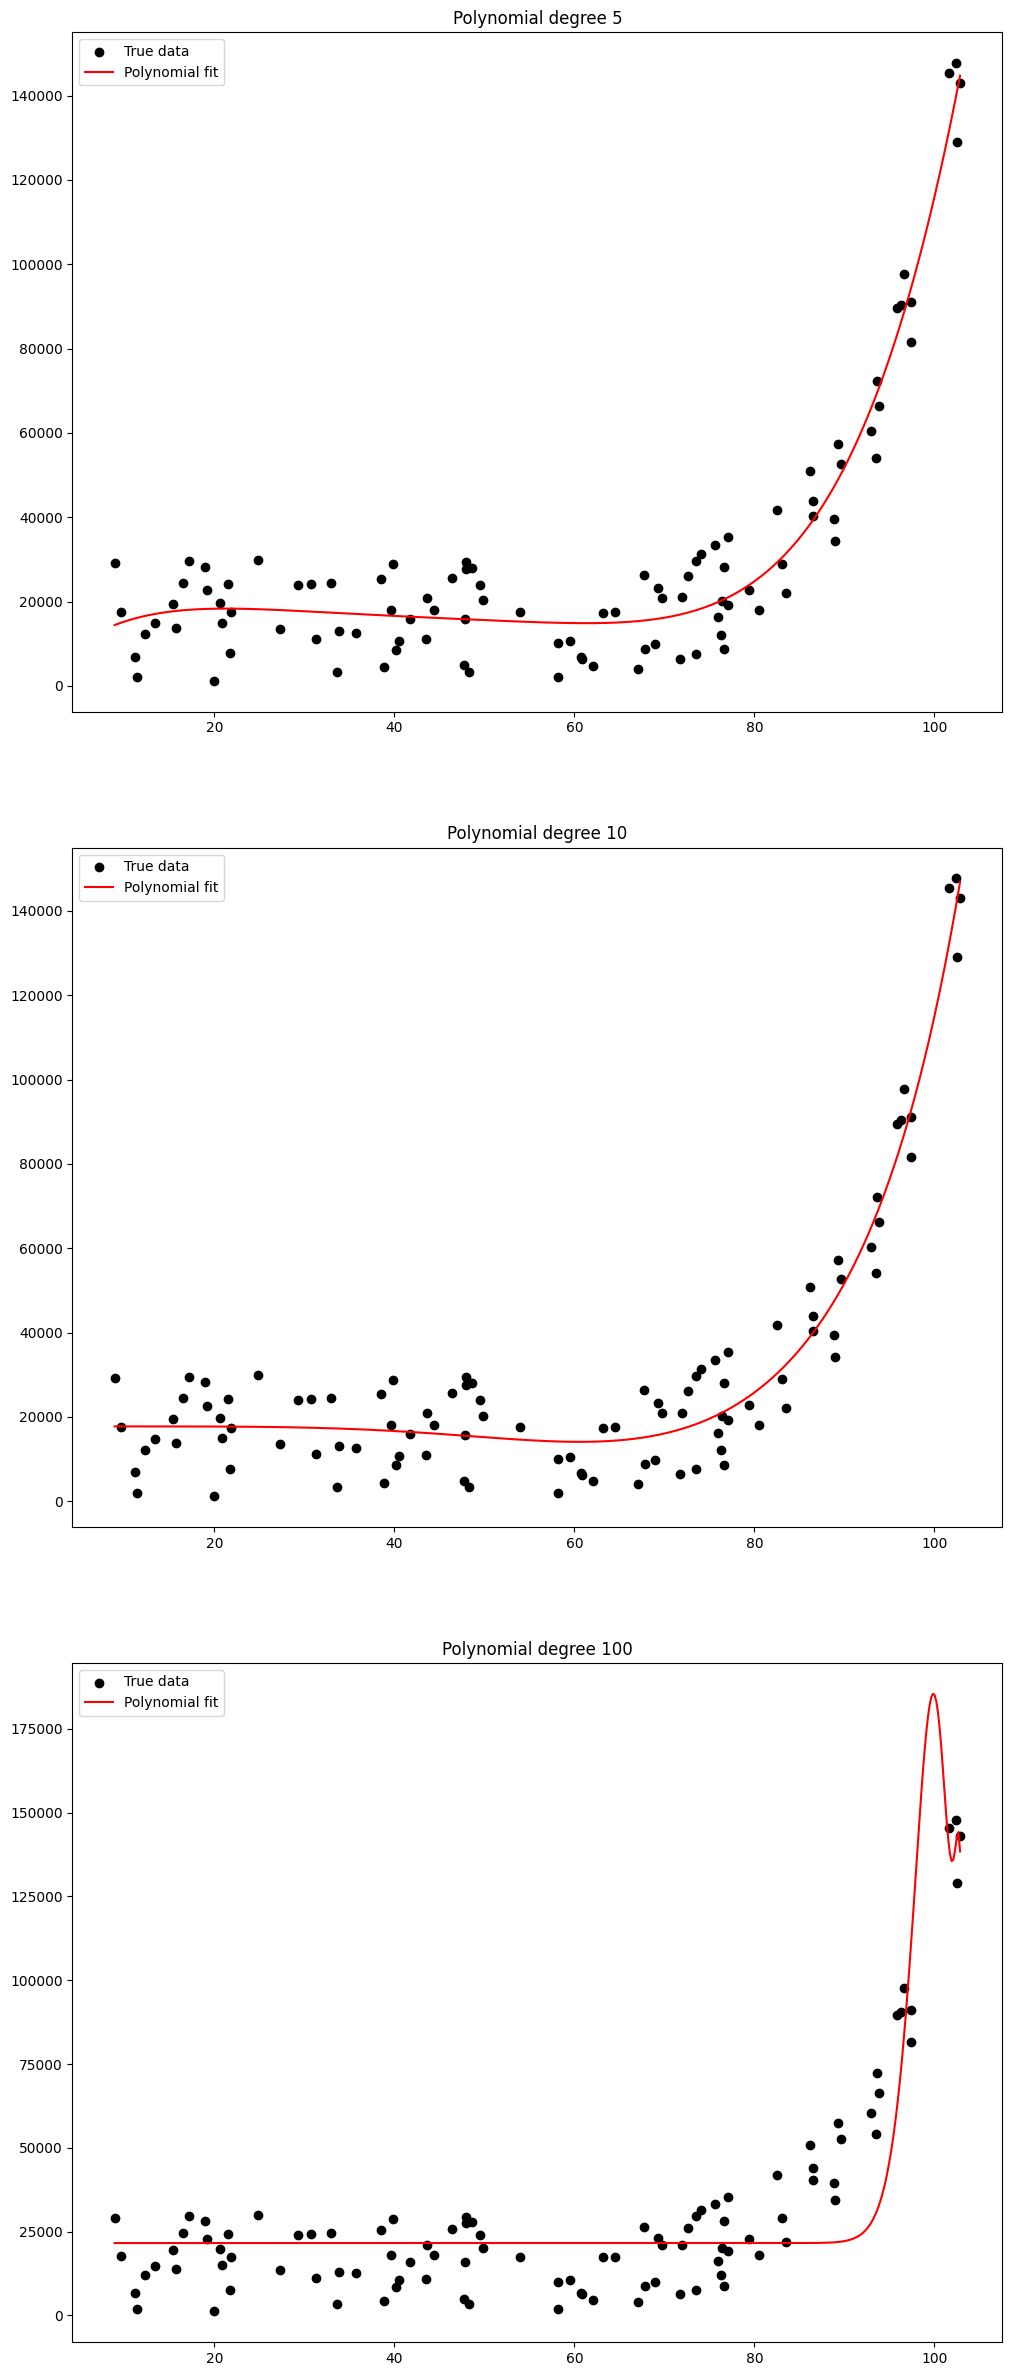

In [7]:
data_kc_class = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML3.1%20polynomial%20features/data/gen_regression.csv")
x_kc_class = data_kc_class[['x']]
y_kc_class = data_kc_class.y

def polynomial(X, Y):

    fig, ax = plt.subplots(3, 1, figsize=(12, 30))
    ax = ax.ravel()

    for n, d in enumerate([5, 10, 100]):
        class_poly = PolynomialFeatures(degree=d)
        x_poly = class_poly.fit_transform(X)

        model_poly = LinearRegression()
        start = time.time()
        model_poly.fit(x_poly, Y)
        end = time.time() - start
        result.append({'Model': f'Poly {n} gen_regression', 'Time': end, 'Score': model_poly.score(x_poly, Y)})
        pred = model_poly.predict(x_poly)
        print(model_poly.score(x_poly, Y))
        # xx, yy = np.meshgrid(
        # np.linspace(X.iloc[:,0].min(), X.iloc[:,0].max(), 300),
        # np.linspace(X.iloc[:,1].min(), X.iloc[:,1].max(), 300)
        # )
        # grid = np.c_[xx.ravel(), yy.ravel()]
        # grid_poly = kc_class_poly.transform(grid)
        # Z = model_poly.predict(grid_poly).reshape(xx.shape)
        #
        # print(X.head())
        #
        # ax[n].contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
        # ax[n].scatter(X, Y, c=pred, cmap='coolwarm')
        x_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
        x_plot_poly = class_poly.transform(x_plot)
        y_plot = model_poly.predict(x_plot_poly)

        # Визуализация
        ax[n].scatter(X, Y, color='black', label='True data')
        ax[n].plot(x_plot, y_plot, color='red', label='Polynomial fit')
        ax[n].set_title(f'Polynomial degree {d}')
        ax[n].legend()

    plt.show()

polynomial(x_kc_class, y_kc_class)

0.916
0.924
0.5


C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages

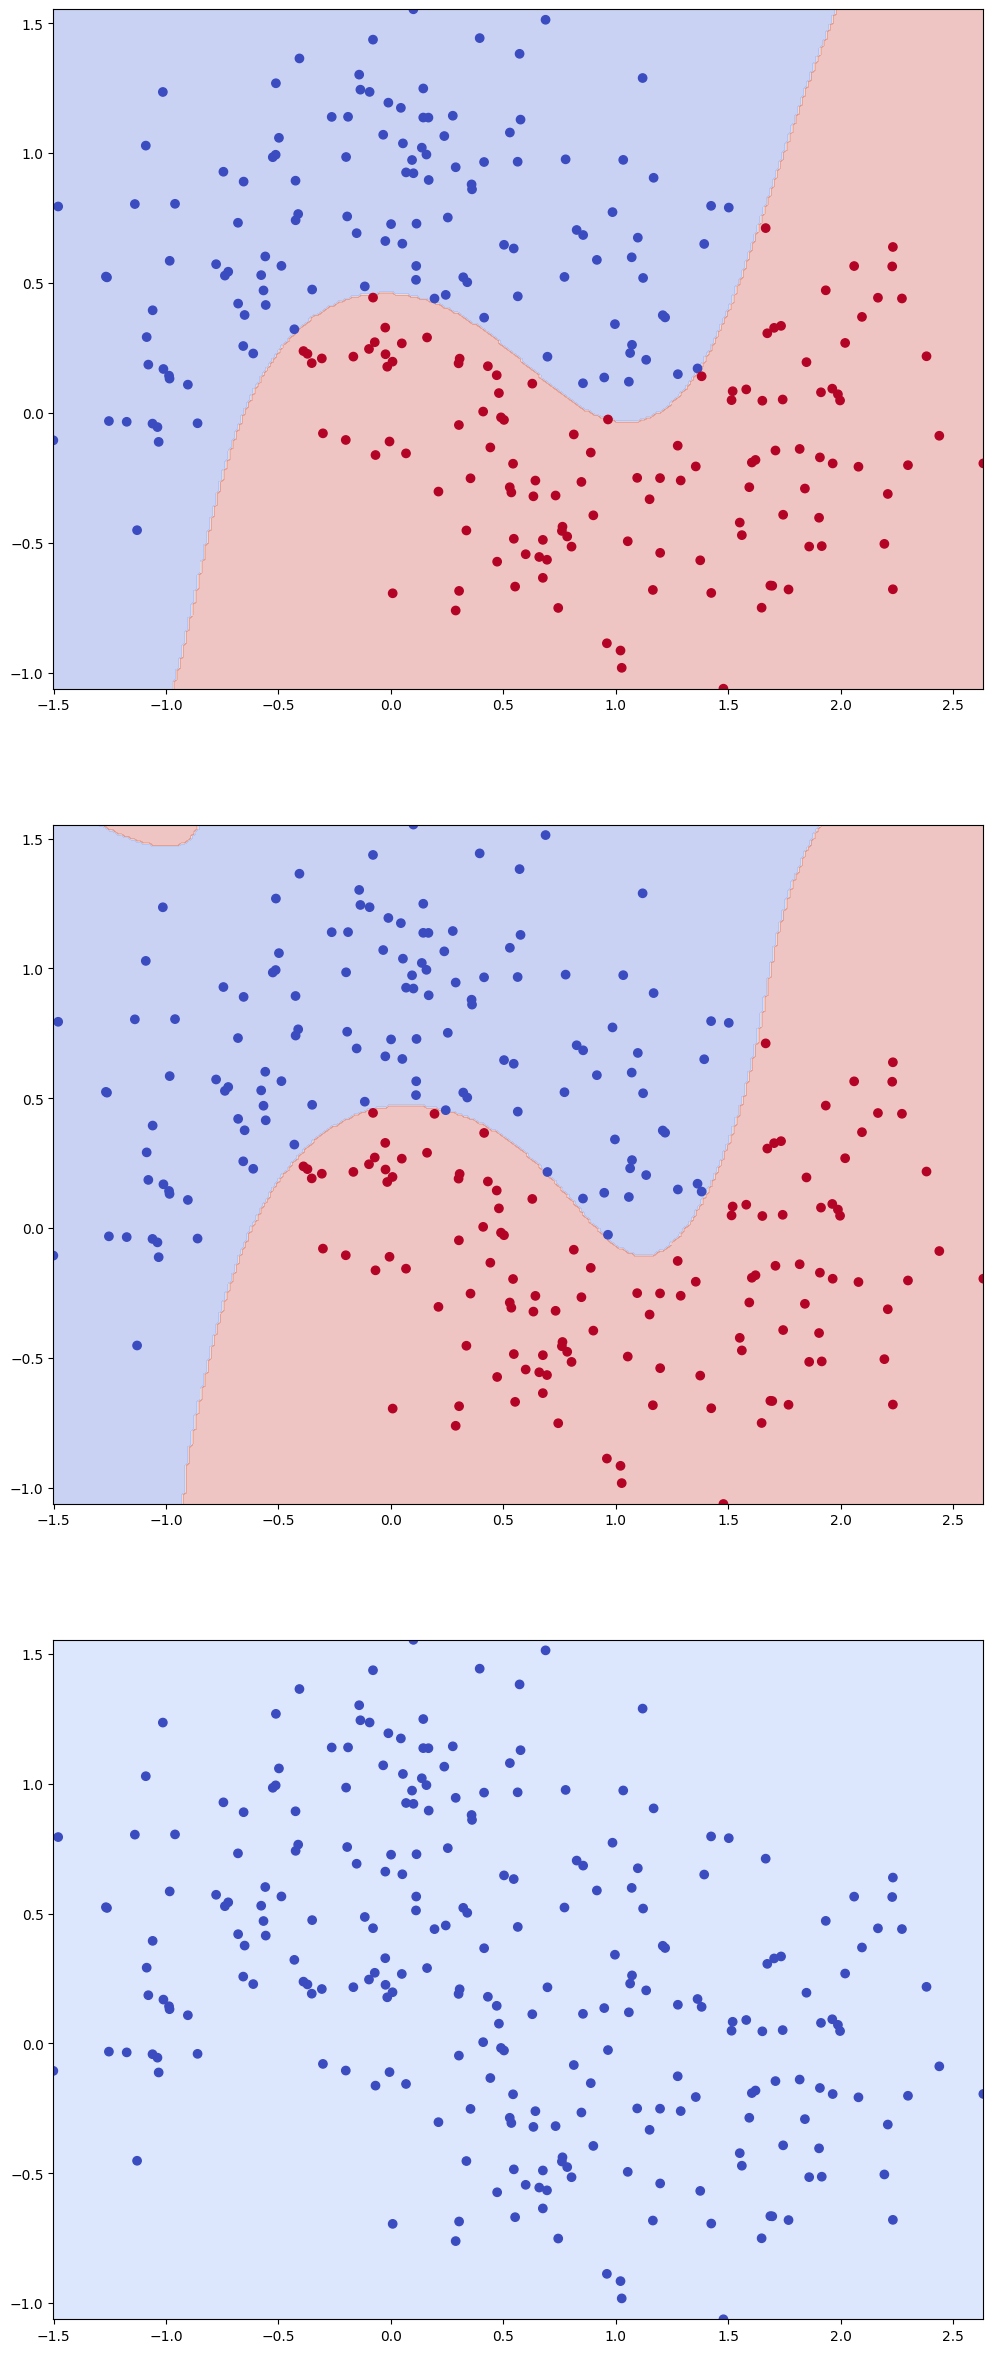

In [8]:
fig, ax = plt.subplots(3, 1, figsize=(12, 30))
ax = ax.ravel()

data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/gen_classification.csv",
                   index_col=0)

Y = data.y
X = data.drop('y', axis=1)

for n, d in enumerate([5, 10, 100]):
    class_poly = PolynomialFeatures(degree=d)
    x_poly = class_poly.fit_transform(X)

    model_poly = LogisticRegression()
    start = time.time()
    model_poly.fit(x_poly, Y)
    end = time.time() - start
    result.append({'Model': f'Poly {n} gen_classification', 'Time': end, 'Score': model_poly.score(x_poly, Y)})
    pred = model_poly.predict(x_poly)
    print(model_poly.score(x_poly, Y))
    xx, yy = np.meshgrid(
    np.linspace(X.iloc[:,0].min(), X.iloc[:,0].max(), 300),
    np.linspace(X.iloc[:,1].min(), X.iloc[:,1].max(), 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_poly = class_poly.transform(grid)
    Z = model_poly.predict(grid_poly).reshape(xx.shape)

    ax[n].contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax[n].scatter(X.iloc[:,0], X.iloc[:,1], c=pred, cmap='coolwarm')
    # x_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
    # x_plot_poly = class_poly.transform(x_plot)
    # y_plot = model_poly.predict(x_plot_poly)

    # Визуализация
    # ax[n].scatter(X, Y, color='black', label='True data')
    # ax[n].plot(x_plot, y_plot, color='red', label='Polynomial fit')
    # ax[n].set_title(f'Polynomial degree {d}')
    # ax[n].legend()

plt.show()

In [10]:
Y = y_kc_prices
X = X_kc_prices
for n, d in enumerate([3]):
    class_poly = PolynomialFeatures(degree=d)

    x_poly = class_poly.fit_transform(X)





    model_poly = LinearRegression()
    start = time.time()
    model_poly.fit(x_poly, Y)
    end = time.time() - start
    result.append({'Model': f'Poly {n} kc_house_data', 'Time': end, 'Score': model_poly.score(x_poly, Y)})
    pred = model_poly.predict(x_poly)
    print(model_poly.score(x_poly, Y))

0.8326020796539016


In [11]:
df = pd.json_normalize(result)
df

,Model,Time,Score
0,Linear gen_regression,0.001100,0.374674
1,Poly gen_regression,0.000710,0.735975
2,Line gen_classification,0.001895,0.832000
3,Poly gen_classification,0.002953,0.900000
4,Line kc_house_data,0.008695,0.699747
5,Poly kc_house_data,1.256236,0.832602
6,Poly 0 gen_regression,0.000562,0.921748
7,Poly 1 gen_regression,0.000592,0.922247
8,Poly 2 gen_regression,0.005796,0.792462
9,Poly 0 gen_classification,0.005923,0.916000
